In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import pycountry
import pycountry_convert as pc

#### Chart 1 – Evolution of GHG growth in the euro area, European Union (EU27) and worldwide;

The dataset reports GHG emissions expressed in megatonnes of CO2 equivalent per year (Mt CO2eq/yr) for each country, as well as aggregates for the EU27 and globally, from 1970 to 2023. Data for the Euro Area was computed by subtracting the values of nonEuro Area countries ('BGR', 'CZE', 'DNK', 'HUN', 'POL', 'ROU', 'SWE') from the EU27 aggregate.

In [2]:
GHG_country = pd.read_excel('data/EDGAR_2024_GHG_booklet_2024.xlsx', sheet_name = 'GHG_totals_by_country').dropna()

In [3]:
# Non-Euro Countries
non_euro_countries = ['BGR', 'CZE', 'DNK', 'HUN', 'POL', 'ROU', 'SWE']

In [4]:
#Compute Eurozone
eurozone = (GHG_country[GHG_country['EDGAR Country Code'] =='EU27'].iloc[:, 2:] - GHG_country[GHG_country['EDGAR Country Code'].isin(non_euro_countries)].iloc[:, 2:].sum()).reset_index(drop = True) #EU27 - NONeuzone
eurozone.insert(0,'Country', 'Eurozone') #Insert Country column with value 'Eurozone' 

In [5]:
#Combine Eurozone with original dataset
GHG_country_1 = GHG_country.copy()
GHG_country_1 = pd.concat([eurozone, GHG_country_1])
GHG_country_1 = GHG_country_1[GHG_country_1['Country'].isin(['EU27', 'GLOBAL TOTAL', 'Eurozone'])].drop('EDGAR Country Code', axis =1 )
GHG_country_1.set_index('Country', inplace = True)

In [6]:
GHG_country_1

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Country,,,,,,,,,,,,,,,,,,,,,
Eurozone,3334.751827,3352.715958,3472.996167,3645.978184,3607.201274,3465.372881,3664.899954,3609.459535,3718.219573,3850.164545,...,2964.721584,3009.534113,3006.736277,3008.942923,2934.460194,2813.433858,2567.020376,2706.660533,2628.340862,2432.460651
EU27,4591.422704,4615.906263,4767.686556,4986.348683,4946.211218,4858.723738,5122.759438,5111.491639,5280.784988,5440.064043,...,3825.528400,3879.728839,3889.377080,3912.269335,3830.658886,3678.016394,3388.278789,3577.018019,3482.310460,3221.794615
GLOBAL TOTAL,24002.751737,24048.408217,24971.278726,26185.418698,26182.148420,26194.503677,27323.858863,27990.648330,28695.045982,29385.106672,...,48930.176837,48808.767176,49058.441256,49878.733809,51026.627449,51278.347920,49327.538885,51568.250032,51968.471601,52962.900859


The growth rate was calculated as a percentage relative to the baseline year of 1970 for each area.

In [7]:
chart1 = GHG_country_1.T.copy()
#Computes growth rates compared to 1970
chart1['Eurozone'] = (chart1['Eurozone'] - chart1['Eurozone'].values[0])/chart1['Eurozone'].values[0] *100
chart1['EU27'] = (chart1['EU27'] - chart1['EU27'].values[0])/chart1['EU27'].values[0] *100
chart1['GLOBAL TOTAL'] = (chart1['GLOBAL TOTAL'] - chart1['GLOBAL TOTAL'].values[0])/chart1['GLOBAL TOTAL'].values[0] *100

chart1.rename(columns ={'EU27': 'European Union (EU27)', 'GLOBAL TOTAL':'Worldwide', 'Eurozone': 'Euro Area'}, inplace = True)

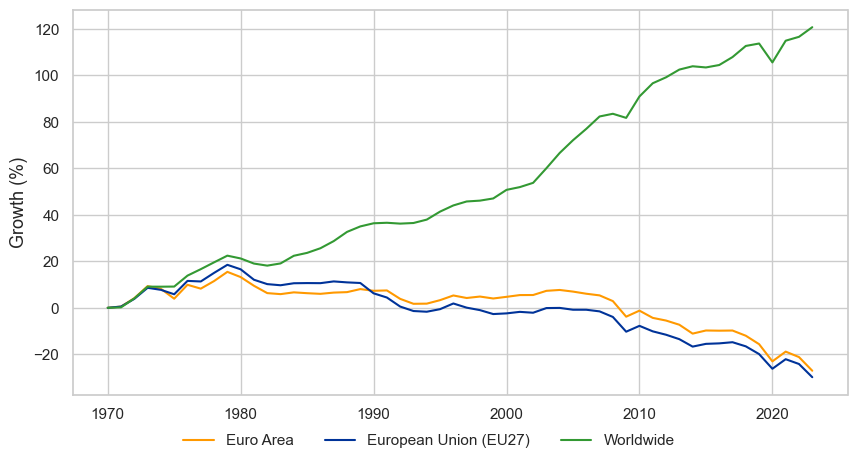

In [8]:
chart1 = pd.melt(chart1.T.reset_index(), id_vars='Country', var_name='Year', value_name='GHG')

sns.set(style="whitegrid")
palette = ["#FF9900","#003399", "#339933"] 
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data = chart1, x = 'Year', y = 'GHG', hue = 'Country', palette = palette, linewidth=1.5)
plt.ylabel('Growth (%)', fontsize=13)
plt.xlabel('', fontsize=0)
plt.legend(loc='center', bbox_to_anchor=(0.46, -0.12), ncols = 3,frameon = False)
#plt.text(1971, -30, 'Baseline year = 1970', fontsize=8, color='black')
#plt.title('Evolution of GHG growth over the years (Baseline: 1970)',fontsize=15)

#### Chart 2 – Comparison of countries’ GHG emissions per capita aggregated according to the World Bank income groups

The income group classifications and population data for each group were obtained from the World Bank's official website, and each country was mapped to the correct group using its country code. 

In [9]:
GHG_country_2 = GHG_country.copy()  # derive from original dataset instead of re-reading the file

In [10]:
income_class = pd.read_excel('data/CLASS.xlsx')
income_class = income_class.dropna(subset= 'Income group') #drop countries without income group . Total of 217 countries 
income_class.head()

,Economy,Code,Region,Income group,Lending category
0,Afghanistan,AFG,South Asia,Low income,IDA
1,Albania,ALB,Europe & Central Asia,Upper middle income,IBRD
2,Algeria,DZA,Middle East & North Africa,Upper middle income,IBRD
3,American Samoa,ASM,East Asia & Pacific,High income,NaN
4,Andorra,AND,Europe & Central Asia,High income,NaN


In [11]:
# Include income group in the dataset, keep relevant columns, and aggregate by income group
GHG_country_2 = income_class.merge(GHG_country_2, left_on = 'Code', right_on = 'EDGAR Country Code')
GHG_country_2.drop(['Economy', 'Code', 'Region','EDGAR Country Code', 'Lending category', 'Country'], axis = 1, inplace = True)
GHG_country_2 = GHG_country_2.groupby('Income group').sum()
GHG_country_2

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Income group,,,,,,,,,,,,,,,,,,,,,
High income,15552.391835,15494.022895,16126.296141,16917.421533,16738.523601,16458.861959,17191.709170,17488.470800,17813.648655,18201.717784,...,18838.016289,18810.406957,18701.126016,18730.695608,18884.515081,18631.051835,17421.381749,18220.998233,18169.478951,17800.844632
Low income,357.129274,359.508719,362.170730,365.532757,373.791986,387.484975,403.967927,415.930400,431.890331,451.919903,...,836.659624,824.945579,851.087413,910.757941,929.768582,961.475842,963.666450,972.180783,991.165865,1008.680527
Lower middle income,1939.360033,1955.054208,2015.436009,2090.270024,2162.830397,2160.877887,2225.457657,2263.903671,2289.303292,2398.008279,...,6361.115798,6487.331981,6670.289761,6927.634161,7165.834556,7243.789852,7024.196390,7384.703629,7595.223919,7916.737767
Upper middle income,5482.095957,5568.625523,5768.892982,6071.222360,6204.263002,6527.783677,6826.288610,7126.562306,7451.225741,7593.045875,...,21412.158370,21165.446206,21289.331357,21721.340376,22446.650350,22875.946190,22798.867416,23817.972052,23903.179913,24829.313775


In [12]:
#Import population data
pop = pd.read_excel('data/Populations.xlsx').set_index('Income group').astype(float)
pop

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Income group,,,,,,,,,,,,,,,,,,,,,
High income,1.009961e+09,1.020996e+09,1.030733e+09,1.040163e+09,1.049400e+09,1.058379e+09,1.066981e+09,1.075522e+09,1.084093e+09,1.092955e+09,...,1.352459e+09,1.360843e+09,1.368877e+09,1.374784e+09,1.379152e+09,1.383372e+09,1.389525e+09,1.387108e+09,1.393037e+09,1.400466e+09
Low income,1.752464e+08,1.799134e+08,1.845816e+08,1.894713e+08,1.945627e+08,1.996874e+08,2.049277e+08,2.101244e+08,2.158695e+08,2.218950e+08,...,5.775864e+08,5.921754e+08,6.078675e+08,6.245570e+08,6.421862e+08,6.607184e+08,6.795607e+08,6.982152e+08,7.168658e+08,7.364664e+08
Lower middle income,1.043648e+09,1.068013e+09,1.093041e+09,1.119788e+09,1.147483e+09,1.176045e+09,1.205182e+09,1.235242e+09,1.265824e+09,1.297669e+09,...,2.721462e+09,2.763351e+09,2.804867e+09,2.846134e+09,2.886705e+09,2.926691e+09,2.966397e+09,3.004163e+09,3.041204e+09,3.079779e+09
Upper middle income,1.440344e+09,1.477949e+09,1.513991e+09,1.549183e+09,1.583012e+09,1.614742e+09,1.645061e+09,1.674062e+09,1.703227e+09,1.732702e+09,...,2.672150e+09,2.694528e+09,2.716146e+09,2.738073e+09,2.758643e+09,2.777172e+09,2.792212e+09,2.803460e+09,2.810662e+09,2.816864e+09


GHG emissions per capita were calculated by dividing the total emissions of each group by its population, and values were then expressed in tonnes of CO2 equivalent per year (t CO2eq/yr) to enhance readability

In [13]:
GHG_country_2 = GHG_country_2/pop*1000000 #Milions bc emission in t

In [14]:
chart2 = GHG_country_2.copy()
chart2 = pd.melt(chart2.reset_index(), id_vars='Income group', var_name='Year', value_name='GHG')

pivot_df = chart2.pivot(index="Year", columns="Income group", values="GHG").T.sort_values(2023).T
years = pivot_df.index
data = pivot_df.T.values

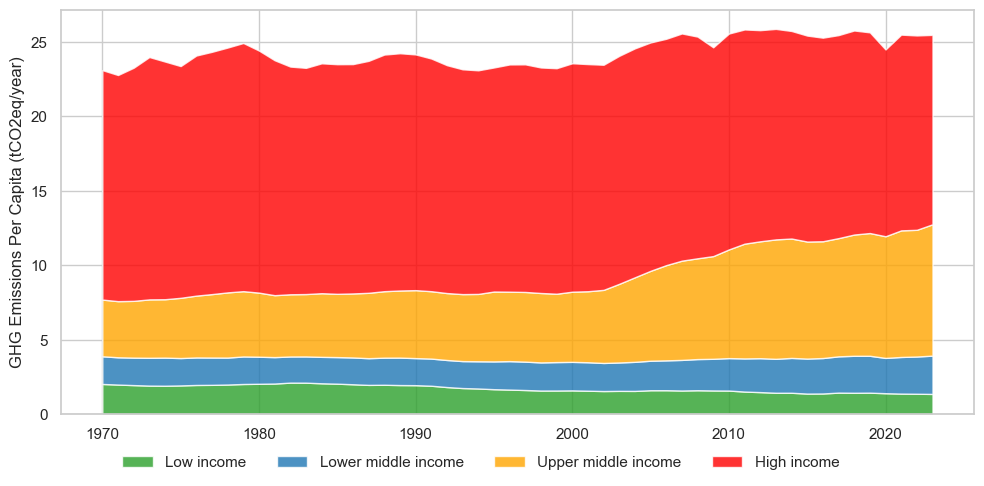

In [15]:
# Plot
sns.set(style = 'whitegrid')
plt.figure(figsize=(10, 5))
plt.stackplot(years.astype(float), data, labels=pivot_df.columns, colors=['#2ca02c','#1f77b4', '#ffa500','#ff0000'], alpha=0.8)
#plt.title("GHG Emissions Per Capita by World Bank Income Groups")
plt.xlabel(" ")
plt.ylabel("GHG Emissions Per Capita (tCO2eq/year)")
plt.legend(loc='center', bbox_to_anchor=(0.46, -0.12), ncols =4,frameon = False)
plt.tight_layout()
plt.show()

#### Chart 3 – Contribution of individual country and continent GHG emissions to total world GHG emissions.

Countries were mapped to each continent using their country code and the Pycountry library in Python. Total emissions by continent were then divided by the global emission. International sources were also displayed to give a correct representation of the global emissions, although not directly allocable to one continent. For simplicity we picked only the main producer of GHG emission
per continent.

In [16]:
# Function to get continent name from alpha-3 country code
def get_continent_by_alpha3(alpha3_code):
    try:
        # Find the country using the alpha-3 code
        country = pycountry.countries.get(alpha_3=alpha3_code)
        if not country:
            return 'Other'
        
        # Convert to alpha-2 code
        country_alpha2 = country.alpha_2
        
        # Get the continent code
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
        
        # Get the continent name
        continent_name = pc.convert_continent_code_to_continent_name(continent_code)
        
        return continent_name
    except (KeyError, AttributeError):
        return 'Other'

In [17]:
GHG_country_3 = GHG_country.copy()  # derive from original dataset instead of re-reading the file

In [18]:
GHG_country_3.insert(2, 'Continent', [get_continent_by_alpha3(code) for code in GHG_country_3['EDGAR Country Code']])

GHG_country_3.loc[GHG_country_3['EDGAR Country Code'] == 'ANT', 'Continent'] = 'South America'
GHG_country_3.loc[GHG_country_3['EDGAR Country Code'] == 'ESH', 'Continent'] = 'Africa'
GHG_country_3.loc[GHG_country_3['EDGAR Country Code'] == 'SCG', 'Continent'] = 'Europe'
GHG_country_3.loc[GHG_country_3['EDGAR Country Code'] == 'TLS', 'Continent'] = 'Asia'

In [19]:
total = GHG_country_3[GHG_country_3.Country == 'GLOBAL TOTAL']

In [20]:
GHG_country_3 = GHG_country_3[GHG_country_3['Continent'] != 'Unknown']
continent = GHG_country_3.iloc[:-2, 2:].groupby('Continent').sum() #Remove EU and global rows
continent = pd.melt(continent.reset_index(), id_vars='Continent', var_name='Years', value_name='GHG')

In [21]:
#%continet over total
chart3 = GHG_country_3.iloc[:-2, 2:].groupby('Continent').sum() / total.iloc[:, 3:].values *100
chart3 


,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Continent,,,,,,,,,,,,,,,,,,,,,
Africa,4.564578,4.606182,4.632427,4.707131,4.783033,4.666532,4.854735,4.824204,4.684053,4.914933,...,5.996049,6.054646,6.102801,6.140834,6.121538,6.197488,6.182192,6.137308,6.114439,6.038941
Asia,26.386456,26.689580,26.585632,26.798198,27.089337,27.988780,27.642871,28.135711,28.484085,28.397199,...,53.451509,53.419084,53.804532,54.288386,54.766153,55.330568,57.168334,57.029689,57.093487,58.203901
Europe,33.653735,33.761719,33.539672,33.572997,33.727113,33.839515,33.834240,33.259804,33.702009,33.796327,...,14.861382,14.903790,14.800910,14.637172,14.359611,14.088967,13.764702,13.858388,13.547669,12.834448
North America,27.565670,27.039376,27.299940,26.979067,26.409624,25.551540,25.766810,25.867208,25.339153,25.048807,...,16.709174,16.538285,16.213175,15.879019,15.906191,15.609411,14.821505,14.914728,14.962986,14.593587
Oceania,1.582866,1.599127,1.606378,1.566122,1.630856,1.659649,1.611021,1.601325,1.530355,1.503579,...,1.447259,1.454323,1.452031,1.450176,1.416287,1.408726,1.406758,1.335835,1.302505,1.286270
Other,2.284519,2.280129,2.307729,2.318587,2.189345,2.064522,2.024976,2.034095,2.015370,2.031926,...,2.429888,2.551877,2.627078,2.699943,2.697130,2.669374,1.974984,1.994272,2.224354,2.350932
South America,3.962177,4.023887,4.028221,4.057899,4.170691,4.229462,4.265348,4.277653,4.244975,4.307229,...,5.104740,5.077994,4.999473,4.904469,4.733091,4.695465,4.681525,4.729779,4.754561,4.691921


In [22]:
chart3 = pd.melt(chart3.reset_index(), id_vars='Continent', var_name='Years', value_name='GHG')

pivot_df = chart3.pivot(index="Years", columns="Continent", values="GHG").fillna(0).T.sort_values(1970, ascending = True).T
pivot_df.rename(columns = {'Other': 'Int. sources'}, inplace = True)
years = pivot_df.index
data = pivot_df.T.values

In [23]:
# Retrieve top emitter in % for each continent in 2023
chart31 = GHG_country_3.iloc[:-2,1:].groupby('Continent', group_keys=False).apply(lambda x: x.nlargest(1, 2023)).drop('Continent', axis = 1).sort_values('Country').set_index('Country').T.drop('International Shipping', axis =1).T.copy()
chart31 = chart31/ total.iloc[:, 3:].values *100
chart31

/var/folders/wj/rf_7mtyj4mz92p07_kctx9t80000gn/T/ipykernel_78895/1291394908.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  chart31 = GHG_country_3.iloc[:-2,1:].groupby('Continent', group_keys=False).apply(lambda x: x.nlargest(1, 2023)).drop('Continent', axis = 1).sort_values('Country').set_index('Country').T.drop('International Shipping', axis =1).T.copy()


,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Country,,,,,,,,,,,,,,,,,,,,,
Australia,1.312462,1.336074,1.335337,1.301465,1.357697,1.392928,1.346768,1.338686,1.274322,1.258704,...,1.226305,1.233505,1.230875,1.229843,1.198044,1.187967,1.185081,1.126154,1.094914,1.079699
Brazil,1.455690,1.486139,1.514247,1.548886,1.654631,1.740161,1.803608,1.823484,1.831739,1.868027,...,2.591722,2.565738,2.502795,2.484105,2.383248,2.379957,2.465153,2.510288,2.498610,2.454867
China,8.478597,8.682948,8.664747,8.423256,8.509292,9.200329,9.042469,9.430693,9.851745,9.763253,...,27.172393,26.878154,26.714496,26.789610,27.349825,27.839296,29.391085,29.428222,29.170844,30.104066
Russia,7.179008,7.226871,7.292482,7.342402,7.692532,8.063547,8.009159,7.991431,8.271796,8.194370,...,4.583413,4.625475,4.580129,4.607558,4.706355,4.841876,4.856548,4.940938,5.044439,5.045115
South Africa,1.004561,1.000599,0.992848,1.019685,1.054490,1.123487,1.135690,1.116619,1.018119,1.027737,...,1.244327,1.195057,1.188973,1.193530,1.172073,1.175644,1.098189,1.068457,1.025674,0.985814
United States,24.116607,23.542351,23.750417,23.406102,22.721798,21.874378,22.118015,22.148237,21.582405,21.298519,...,13.178639,12.966928,12.650799,12.333457,12.419789,12.115166,11.497846,11.630511,11.634392,11.254679


In [24]:
chart31 = pd.melt(chart31.reset_index(), id_vars='Country', var_name='Years', value_name='GHG')

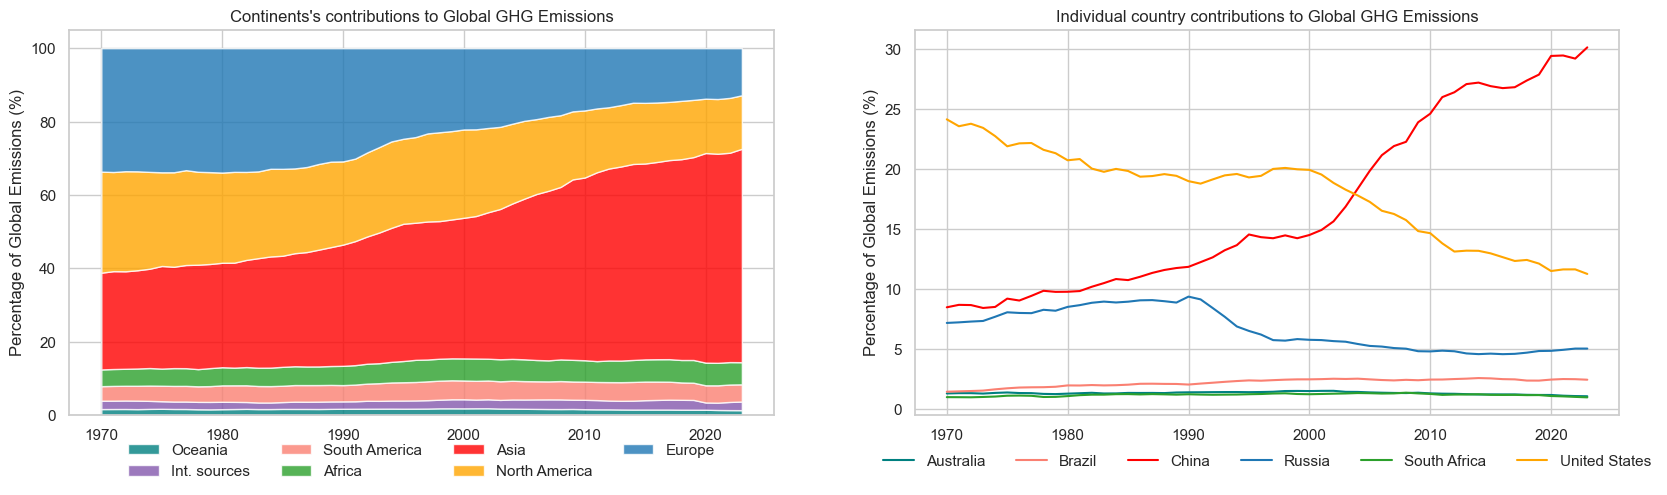

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5))  
axs[0].stackplot(years.astype(float), data, labels=pivot_df.columns, colors=['teal', '#8457ad', 'salmon', '#2ca02c', '#ff0000','#ffa500', '#1f77b4'], alpha=0.8)
axs[0].set_title("Continents's contributions to Global GHG Emissions")
axs[0].set_xlabel(" ")
axs[0].set_ylabel("Percentage of Global Emissions (%)")
axs[0].legend(loc='center', bbox_to_anchor=(0.5, -0.12), ncols =4,frameon = False)

sns.lineplot(data = chart31, x= 'Years', y = 'GHG', hue ='Country', palette=['teal', 'salmon', '#ff0000', '#1f77b4', '#2ca02c', '#ffa500'], linewidth=1.5, ax = axs[1])
axs[1].set_title("Individual country contributions to Global GHG Emissions")
axs[1].set_xlabel("")
axs[1].set_ylabel("Percentage of Global Emissions (%)")
axs[1].legend(loc='center', bbox_to_anchor=(0.5, -0.12), ncols =6,frameon = False)